# Credit Card Fraud Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('creditcard.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 284807 rindas, 31 kolonnas


In [2]:
# Datu tipi un trūkstošās vērtības
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
# Trūkstošo vērtību vizualizācija
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("✅ Nav trūkstošu vērtību — grafiks nav nepieciešams!")
else:
    plt.figure(figsize=(8, 4))
    missing.plot(kind='bar', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.ylabel('Skaits')
    plt.tight_layout()
    plt.show()

✅ Nav trūkstošu vērtību — grafiks nav nepieciešams!


In [5]:
# Skaitlisko kolonnu statistika
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# Target mainīgā sadalījums
print(df['Class'].value_counts())
print(f"\nKrāpšanas gadījumu īpatsvars:{df['Class'].mean():.1%}")

Class
0    284315
1       492
Name: count, dtype: int64

Krāpšanas gadījumu īpatsvars:0.2%


**Ņemot vērā, ka no 284 807 darījumiem tikai 492 jeb 0,2% ir krāpnieciski, veidojas klašu nelīdzsvarotība, un modelis, kurš vienmēr prognozē "likumīgs", sasniegs 99,8% precizitāti, kas ir bezjēdzīgi. Tapēc modelēšanā jāņem vērā sekojošais:**
  
- **Nelīdzsvarotības risināšana** - kā modelis tiks izmantots Random Forest, jo labi tiek galā ar nelīdzsvarotām klasēm un ir izturīgs pret outlieriem.

- **Time kolonna** - svarīgi ievērot laika secību, tāpēc train/test sadalīšanai ieteicams izmantot nevis nejauši (random split), bet gan hronoloģiski.

- **Amount kolonna** - tā nav normalizēta (max = 25 691), tāpēc to vajadzēs mērogot.

- **Metrika** - nevis accuracy, bet GridSearchCV

**Kodā tiks iekļauta *predict_proba* metode, kas atgriež varbūtību, nevis tikai klasi (0 vai 1), lai noteiktu krāpšanas varbūtību. Tas ir svarīgi ROC-AUC aprēķinam, kam vajag pakāpenisku varbūtību, lai varētu zīmēt ROC līkni pie dažādiem sliekšņiem. Rezultātā ir svarīgi noteikt arī slieksni robežās no 0 līdz 1, kas attiecīgi prognozēs krāpšanas varbūtību, piemēram, ja gribam īpaši ierobežot krāpšanu, slieksni jānosaka zemāku (tuvāku nullei)**

In [3]:
# Kārto hronoloģiski (TimeSeriesSplit prasa secību)
df = df.sort_values('Time').reset_index(drop=True)

# Atdala pazīmes un mērķa mainīgo
X = df.drop(columns=['Class'])
y = df['Class']

# Sadala train/test (80/20), respektējot laika secību
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Krāpšana train: {y_train.sum()} | Krāpšana test: {y_test.sum()}")

Train: (227845, 30), Test: (56962, 30)
Krāpšana train: 417 | Krāpšana test: 75


In [4]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__class_weight': ['balanced', None]
}

search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

print("Labākie parametri:", search.best_params_)
print("Labākais ROC-AUC:", search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Labākie parametri: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Labākais ROC-AUC: 0.975911804359314


In [6]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score)

# Labākie parametri
print("Labākie parametri:", search.best_params_)
print("Labākais ROC-AUC (CV):", round(search.best_score_, 4))

# Prognozes uz test kopas
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Galvenās metrikas
print("\nKlasifikācijas pārskats:")
print(classification_report(y_test, y_pred, target_names=['Likumīgs', 'Krāpšana']))

print("ROC-AUC (test):", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC  (test):", round(average_precision_score(y_test, y_proba), 4))

# Confusion matrix
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_proba.round()))

Labākie parametri: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Labākais ROC-AUC (CV): 0.9759

Klasifikācijas pārskats:
              precision    recall  f1-score   support

    Likumīgs       1.00      1.00      1.00     56887
    Krāpšana       0.68      0.79      0.73        75

    accuracy                           1.00     56962
   macro avg       0.84      0.89      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC (test): 0.9903
PR-AUC  (test): 0.806

Confusion matrix:
[[56859    28]
 [   16    59]]


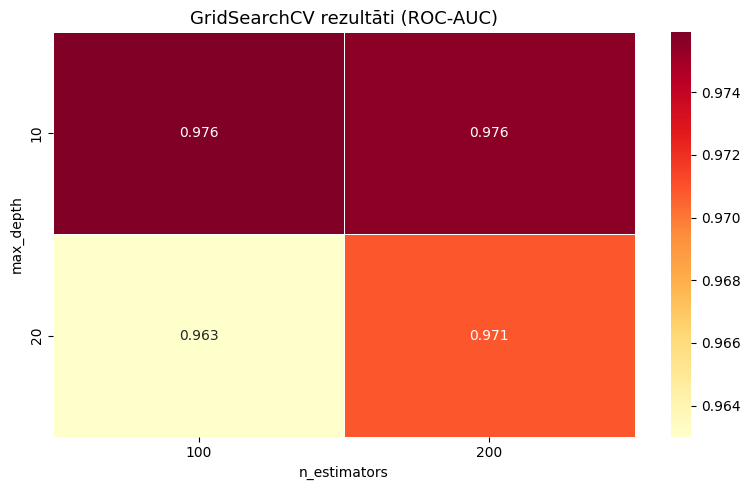

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Iegūst rezultātus no GridSearchCV
results = pd.DataFrame(search.cv_results_)

# Filtrē tikai labākos class_weight rezultātus (vidējais pa min_samples_split)
pivot = results.pivot_table(
    index='param_model__max_depth',
    columns='param_model__n_estimators',
    values='mean_test_score',
    aggfunc='max'
)

# Zīmē heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)

ax.set_title('GridSearchCV rezultāti (ROC-AUC)', fontsize=13)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150)
plt.show()

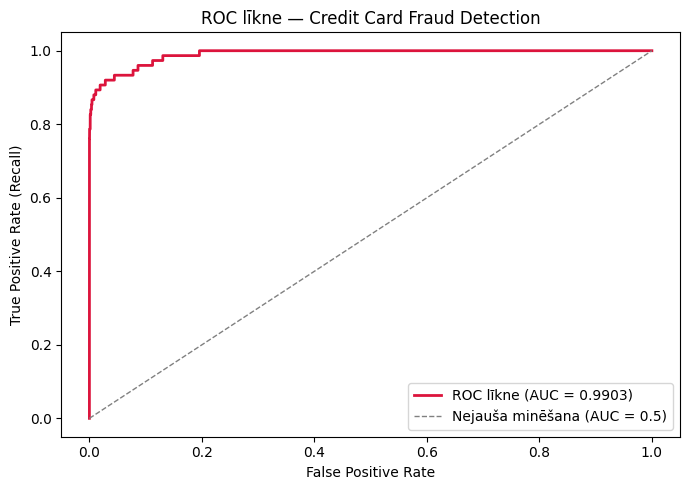

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Iegūst varbūtības
y_proba = best_model.predict_proba(X_test)[:, 1]

# Aprēķina ROC līkni
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Zīmē
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC līkne (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Nejauša minēšana (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC līkne — Credit Card Fraud Detection')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [10]:
# Vietā predict(), izmanto varbūtības ar zemāku slieksni
threshold = 0.3  # vietā noklusētā 0.5
y_pred_custom = (y_proba >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom, target_names=['Likumīgs', 'Krāpšana']))

              precision    recall  f1-score   support

    Likumīgs       1.00      0.99      1.00     56887
    Krāpšana       0.18      0.87      0.30        75

    accuracy                           0.99     56962
   macro avg       0.59      0.93      0.65     56962
weighted avg       1.00      0.99      1.00     56962



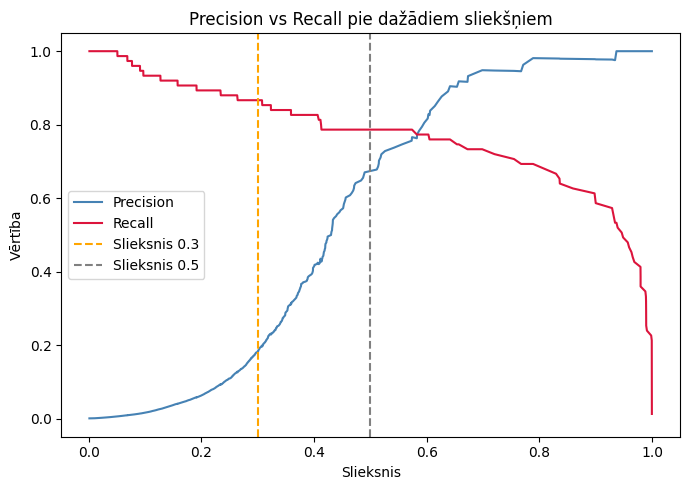

In [11]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='crimson')
ax.axvline(x=0.3, color='orange', linestyle='--', label='Slieksnis 0.3')
ax.axvline(x=0.5, color='gray', linestyle='--', label='Slieksnis 0.5')
ax.set_xlabel('Slieksnis')
ax.set_ylabel('Vērtība')
ax.set_title('Precision vs Recall pie dažādiem sliekšņiem')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print(f"Optimālais slieksnis: {best_threshold:.3f}")
print(f"Maksimālais F1: {best_f1:.3f}")

Optimālais slieksnis: 0.699
Maksimālais F1: 0.827


In [13]:
y_pred_optimal = (y_proba >= 0.699).astype(int)
print(classification_report(y_test, y_pred_optimal, target_names=['Likumīgs', 'Krāpšana']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

              precision    recall  f1-score   support

    Likumīgs       1.00      1.00      1.00     56887
    Krāpšana       0.95      0.72      0.82        75

    accuracy                           1.00     56962
   macro avg       0.97      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Confusion matrix:
[[56884     3]
 [   21    54]]


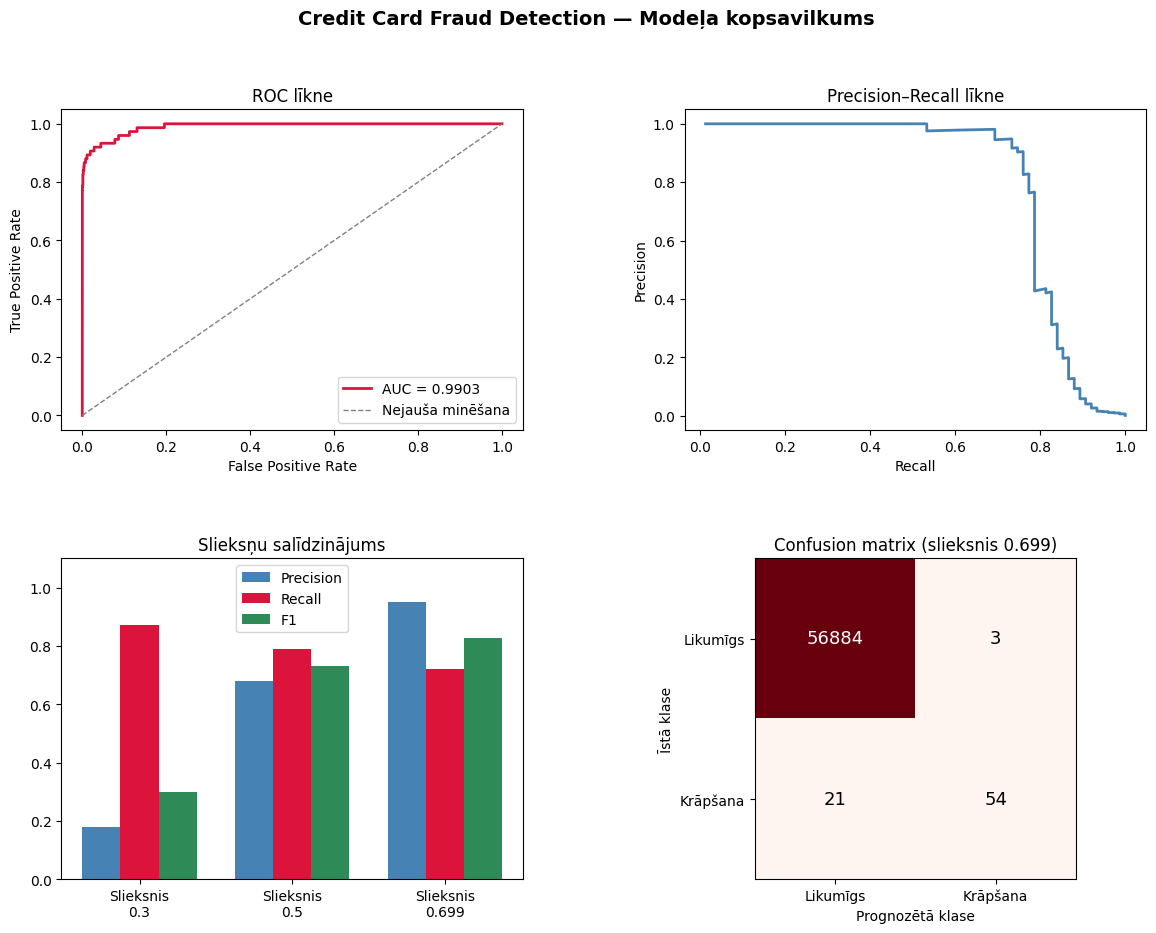

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- 1. ROC līkne ---
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
ax1.plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {auc_score:.4f}')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Nejauša minēšana')
ax1.set_title('ROC līkne')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

# --- 2. Precision–Recall līkne ---
ax2 = fig.add_subplot(gs[0, 1])
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
ax2.plot(recalls[:-1], precisions[:-1], color='steelblue', lw=2)
ax2.set_title('Precision–Recall līkne')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')

# --- 3. Slieksņu salīdzinājums ---
ax3 = fig.add_subplot(gs[1, 0])
sliekšņi = ['0.3', '0.5', '0.699']
precision_vals = [0.18, 0.68, 0.95]
recall_vals = [0.87, 0.79, 0.72]
f1_vals = [0.30, 0.73, 0.827]
x = np.arange(len(sliekšņi))
width = 0.25
ax3.bar(x - width, precision_vals, width, label='Precision', color='steelblue')
ax3.bar(x, recall_vals, width, label='Recall', color='crimson')
ax3.bar(x + width, f1_vals, width, label='F1', color='seagreen')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Slieksnis\n{s}' for s in sliekšņi])
ax3.set_ylim(0, 1.1)
ax3.set_title('Slieksņu salīdzinājums')
ax3.legend()

# --- 4. Confusion matrix (optimālais slieksnis 0.699) ---
ax4 = fig.add_subplot(gs[1, 1])
cm = np.array([[56884, 3], [21, 54]])
im = ax4.imshow(cm, interpolation='nearest', cmap='Reds')
ax4.set_title('Confusion matrix (slieksnis 0.699)')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Likumīgs', 'Krāpšana'])
ax4.set_yticklabels(['Likumīgs', 'Krāpšana'])
ax4.set_xlabel('Prognozētā klase')
ax4.set_ylabel('Īstā klase')
for i in range(2):
    for j in range(2):
        ax4.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > 1000 else 'black', fontsize=13)

fig.suptitle('Credit Card Fraud Detection — Modeļa kopsavilkums', fontsize=14, fontweight='bold')
plt.savefig('fraud_detection_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Secinājumi

| Metrika | Slieksnis 0.3 | Slieksnis 0.5 | Slieksnis 0.699 |
|---|---|---|---|
| Precision | 0.18 | 0.68 | 0.95 |
| Recall | 0.87 | 0.79 | 0.72 |
| F1 | 0.30 | 0.73 | 0.827 |
| FP (kļūdaini bloķēti) | daudz | 28 | 3 |
| FN (nepamanītas krāpšanas) | 10 | 16 | 21 |

**Precisison** - no visiem, ko modelis atzīmēja kā krāpšanu, cik % tiešām bija krāpšana;

**Recall** - no visām īstajām krāpšanām, cik % modelis atrada;

**F1** - harmoniskais vidējais starp Precision un Recall, viens līdzsvarots skaitlis (Kāds ir kopējais balanss starp abiem).

*Sākotnēji ROC līknei tika noteikts slieksnis 0.5, jo fraud detection kontekstā tas ir optimālais slieksnis -> Recall joprojām ir augsts un Precision nav sabrucis. Lai atrastu matemātiski precīzāko punktu, tika aprēķināts slieksnis ar maksimālo F1. Rezultātā tika iegūts slieksnis **0.699**, secinot, ka modelis pie augstāka sliekšņa ir precīzāks, nezaudējot pārāk daudz Recall.*

- Slieksnis 0.699 ir matemātiski optimālais, jo F1 = 0.827 ir labākais no visiem trim apskatītiajiem sliekšņiem. Precision 0.95 nozīmē, ka gandrīz katrs "krāpšana" signāls ir patiess — tikai 3 likumīgi klienti kļūdaini bloķēti.

- biznesa kontekstā izvēle atkarīga no prioritātes, vai slieksnis 0.5 ar augstāku Recall ir vērtīgāks, jo atrod par 5 krāpšanām vairāk, bet par to maksā ar 25 papildu kļūdaini bloķētiem klientiem.